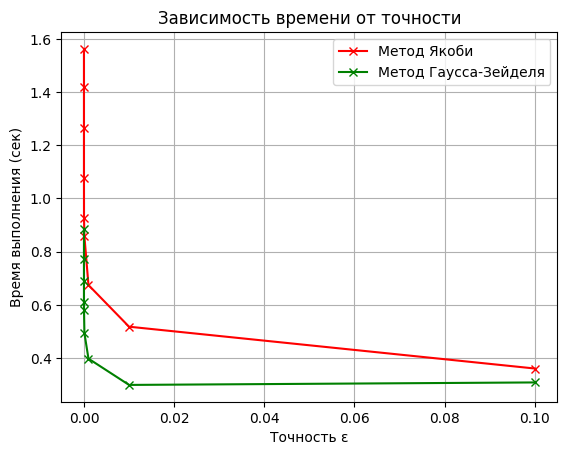

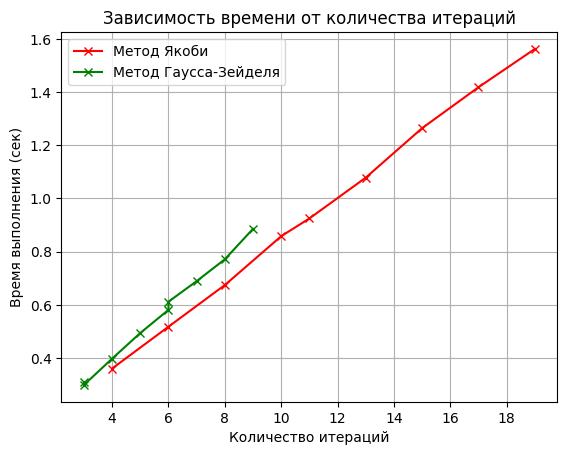

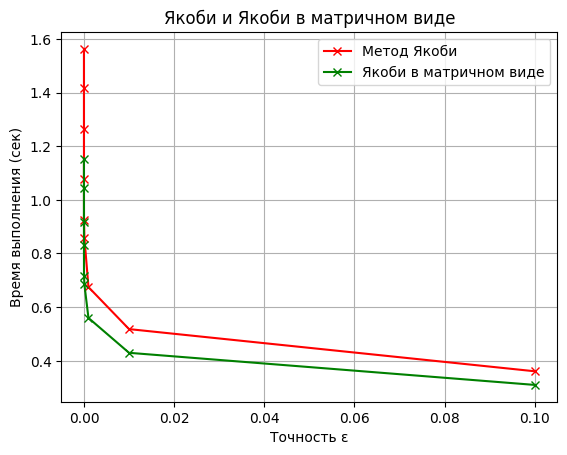

In [3]:
import numpy as np
import time
import matplotlib.pyplot as plt

def LU_razl (A, b):
    n = len(A)
    L = np.zeros((n,n))
    U = np.zeros((n,n))

    for i in range(n):
        for j in range(n):
            if i >= j: #L
                L[i][j] = A[i][j] - sum(L[i][k] * U[k][j] for k in range(j))
            else:
                U[i][j] = (A[i][j] - sum(L[i][k] * U[k][j] for k in range(j)))/L[i][i]
            U[i][i] = 1

    y = np.zeros(n)
    for i in range(n):
        y[i] = (b[i] - sum(L[i][k] * y[k] for k in range(i))) / L[i][i]

    x = np.zeros(n)
    for i in range(n-1, -1, -1):
        x[i] = y[i] - sum(U[i][j] * x[j] for j in range(i+1, n))
    
    return x
    

def Yakobi (A, b, eps):
    n = len(A)
    x = np.zeros(n)
    x_new = np.zeros(n)
    count = 0

    while True:
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i]= (b[i] - s) / A[i][i]

        count += 1
        if np.sqrt(sum((x[j] - x_new[j])**2 for j in range(n))) < eps:
            break
        x = x_new.copy()
            
    return x_new, count 

def Yakobi_M(A, b, eps):
    n = len(A)
    D_inv = np.diag(1 / np.diag(A))  # обратная диагональ
    R = A - np.diag(np.diag(A))      # матрица без диагонали
    x = np.zeros(n)
    
    while True:
        x_new = D_inv @ (b - R @ x)
        if np.linalg.norm(x_new - x) < eps:
            break
        x = x_new
    return x
    

def GZ_metod (A, b, eps):
    n = len(A)
    x = np.zeros(n)
    count = 0

    while True:
        x_old = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x[j] for j in range(i))      # новые x
            s2 = sum(A[i][j] * x_old[j] for j in range(i+1, n))  # старые x
            x[i] = (b[i] - s1 - s2) / A[i][i]

        count+=1
        if np.sqrt(sum((x[j] - x_old[j])**2 for j in range(n))) < eps:
            break
    return x, count



A = np.array([[10, 1, 1],
              [2, 10, 1],
              [2, 2, 10]])
b = np.array([12, 13, 14])

def time_test(f, *args, **kwargs):
    start = time.time()
    for _ in range(10000):
        f(*args, **kwargs)
    end = time.time()
    return end - start

time_test(LU_razl, A, b)
time_test(Yakobi, A, b, eps=0.001)
time_test(GZ_metod, A, b, eps=0.001)

Val_eps = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8, 1e-9]
iter_Y = []
iter_GZ = []
eps_Y = []
eps_GZ = []
eps_Y_M = []
for eps in Val_eps:
    eps_Y.append(time_test(Yakobi, A, b, eps = eps))
    eps_GZ.append(time_test(GZ_metod, A, b, eps = eps))
    eps_Y_M.append(time_test(Yakobi_M, A, b, eps=eps))

    _,iter_y = Yakobi(A, b, eps=eps)
    iter_Y.append(iter_y)
    _,iter_gz = GZ_metod(A, b, eps=eps)
    iter_GZ.append(iter_gz)


plt.figure(1)
plt.plot(Val_eps, eps_Y, 'rx-', label="Метод Якоби")
plt.plot(Val_eps, eps_GZ, 'gx-', label="Метод Гаусса-Зейделя")
plt.legend()
plt.xlabel("Точность ε")
plt.ylabel("Время выполнения (сек)")
plt.title("Зависимость времени от точности")
plt.grid()

plt.figure(2)
plt.plot(iter_Y, eps_Y, 'rx-', label="Метод Якоби")
plt.plot(iter_GZ, eps_GZ, 'gx-', label="Метод Гаусса-Зейделя")
plt.legend()
plt.xlabel("Количество итераций")
plt.ylabel("Время выполнения (сек)")
plt.title("Зависимость времени от количества итераций")
plt.grid()

plt.figure(3)
plt.plot(Val_eps, eps_Y, 'rx-', label="Метод Якоби")
plt.plot(Val_eps, eps_Y_M, 'gx-', label="Якоби в матричном виде")
plt.legend()
plt.xlabel("Точность ε")
plt.ylabel("Время выполнения (сек)")
plt.title("Якоби и Якоби в матричном виде")
plt.grid()

plt.show()